# Customer Review Sentiment Analysis — Data Cleaning and EDA

This notebook prepares the **Women’s Clothing E-Commerce Reviews** dataset for a sentiment analysis project.

## What this notebook does
- loads the raw review dataset
- standardises column names
- handles missing values and duplicate reviews
- combines review title and body text
- maps star ratings into **negative / neutral / positive**
- performs exploratory data analysis
- saves a cleaned dataset for modeling

## Dataset snapshot
- raw rows: **23,486**
- raw columns: **11**
- missing `Review Text`: **845**
- rows after text cleaning and duplicate removal: **22,635**

## Sentiment mapping
- **1–2** → negative
- **3** → neutral
- **4–5** → positive

## 1. Imports and settings

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## 2. Locate and load the dataset

This cell tries a few common locations so the notebook still works after you move it into your project folder.

In [2]:
def find_dataset(filename: str) -> Path:
    candidate_paths = [
        Path(filename),
        Path("./data/raw") / filename,
        Path("../data/raw") / filename,
        Path("/mnt/data") / filename,
    ]

    for path in candidate_paths:
        if path.exists():
            return path.resolve()

    raise FileNotFoundError(
        f"Could not find {filename}. Place it in the notebook folder, ./data/raw, ../data/raw, or /mnt/data."
    )

RAW_PATH = find_dataset("Womens Clothing E-Commerce Reviews.csv")
RAW_PATH

WindowsPath('C:/Users/Owen/Documents/Hertsfordshire/Projects/customer-review/data/raw/Womens Clothing E-Commerce Reviews.csv')

In [3]:
df = pd.read_csv(RAW_PATH)

print(f"Shape: {df.shape}")
display(df.head())

Shape: (23486, 11)


,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have orde...",5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my u...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great comp...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings...,5,1,6,General,Tops,Blouses


## 3. Inspect the raw data

In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

Columns:
['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']

Missing values:


,missing_count
Title,3810
Review Text,845
Department Name,14
Class Name,14
Division Name,14
Unnamed: 0,0
Clothing ID,0
Age,0
Rating,0
Recommended IND,0


## 4. Rename columns and keep the fields needed for the project

We keep the review text, rating, and useful metadata for later dashboard insights.

In [5]:
df = df.rename(columns={
    "Clothing ID": "clothing_id",
    "Age": "age",
    "Title": "title",
    "Review Text": "review_text",
    "Rating": "rating",
    "Recommended IND": "recommended_ind",
    "Positive Feedback Count": "positive_feedback_count",
    "Division Name": "division_name",
    "Department Name": "department_name",
    "Class Name": "class_name"
})

columns_to_keep = [
    "clothing_id",
    "age",
    "title",
    "review_text",
    "rating",
    "recommended_ind",
    "positive_feedback_count",
    "division_name",
    "department_name",
    "class_name"
]

df = df[columns_to_keep].copy()
print(f"Shape after column selection: {df.shape}")
display(df.head())

Shape after column selection: (23486, 10)


,clothing_id,age,title,review_text,rating,recommended_ind,positive_feedback_count,division_name,department_name,class_name
0,767,33,NaN,Absolutely wonderful - silky and sexy and comfortable,4,1,0,Initmates,Intimate,Intimates
1,1080,34,NaN,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have orde...",5,1,4,General,Dresses,Dresses
2,1077,60,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my u...,3,0,0,General,Dresses,Dresses
3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great comp...",5,1,0,General Petite,Bottoms,Pants
4,847,47,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings...,5,1,6,General,Tops,Blouses


## 5. Clean missing text fields

In [6]:
# Drop rows where the main review text is missing
df = df.dropna(subset=["review_text"]).copy()

# Fill missing titles so they can still be combined safely
df["title"] = df["title"].fillna("")

# Standardise text columns
df["title"] = df["title"].astype(str).str.strip()
df["review_text"] = df["review_text"].astype(str).str.strip()

# Remove blank review rows
df = df[df["review_text"] != ""].copy()

print(f"Shape after text cleaning: {df.shape}")

Shape after text cleaning: (22641, 10)


## 6. Combine title and review text

In [7]:
df["full_review"] = (df["title"] + " " + df["review_text"]).str.strip()

display(df[["title", "review_text", "full_review"]].head())

,title,review_text,full_review
0,,Absolutely wonderful - silky and sexy and comfortable,Absolutely wonderful - silky and sexy and comfortable
1,,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have orde...","Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have orde..."
2,Some major design flaws,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my u...,Some major design flaws I had such high hopes for this dress and really wanted it to work for me. i initially ordere...
3,My favorite buy!,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great comp...","My favorite buy! I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothi..."
4,Flattering shirt,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings...,Flattering shirt This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to w...


## 7. Create sentiment labels from star ratings

In [8]:
def map_sentiment(rating):
    if rating in [1, 2]:
        return "negative"
    if rating == 3:
        return "neutral"
    if rating in [4, 5]:
        return "positive"
    return np.nan

df["sentiment"] = df["rating"].apply(map_sentiment)
df = df.dropna(subset=["sentiment"]).copy()

display(df["sentiment"].value_counts().to_frame("count"))

,count
sentiment,
positive,17448
neutral,2823
negative,2370


## 8. Light text cleaning

This is intentionally light. For sentiment tasks, words like *not*, *never*, and contractions can matter.

In [9]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)         # remove URLs
    text = re.sub(r"<.*?>", "", text)                    # remove HTML
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)        # keep words, digits, apostrophes
    text = re.sub(r"\s+", " ", text).strip()            # normalise spaces
    return text

df["clean_review"] = df["full_review"].apply(clean_text)

display(df[["full_review", "clean_review", "sentiment"]].head())

,full_review,clean_review,sentiment
0,Absolutely wonderful - silky and sexy and comfortable,absolutely wonderful silky and sexy and comfortable,positive
1,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have orde...",love this dress it's sooo pretty i happened to find it in a store and i'm glad i did bc i never would have ordered i...,positive
2,Some major design flaws I had such high hopes for this dress and really wanted it to work for me. i initially ordere...,some major design flaws i had such high hopes for this dress and really wanted it to work for me i initially ordered...,neutral
3,"My favorite buy! I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothi...",my favorite buy i love love love this jumpsuit it's fun flirty and fabulous every time i wear it i get nothing but g...,positive
4,Flattering shirt This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to w...,flattering shirt this shirt is very flattering to all due to the adjustable front tie it is the perfect length to we...,positive


## 9. Remove duplicate reviews

In [10]:
rows_before = len(df)
df = df.drop_duplicates(subset=["clean_review", "rating"]).copy()
rows_after = len(df)

print(f"Duplicates removed: {rows_before - rows_after}")
print(f"Final working shape: {df.shape}")

Duplicates removed: 6
Final working shape: (22635, 13)


## 10. Feature engineering for EDA

In [11]:
df["review_length_words"] = df["clean_review"].apply(lambda text: len(text.split()))
df["review_length_chars"] = df["clean_review"].apply(len)

display(df[["clean_review", "review_length_words", "review_length_chars"]].head())

,clean_review,review_length_words,review_length_chars
0,absolutely wonderful silky and sexy and comfortable,7,51
1,love this dress it's sooo pretty i happened to find it in a store and i'm glad i did bc i never would have ordered i...,62,289
2,some major design flaws i had such high hopes for this dress and really wanted it to work for me i initially ordered...,101,509
3,my favorite buy i love love love this jumpsuit it's fun flirty and fabulous every time i wear it i get nothing but g...,25,132
4,flattering shirt this shirt is very flattering to all due to the adjustable front tie it is the perfect length to we...,38,204


## 11. EDA — sentiment class distribution

,count
sentiment,
positive,17442
neutral,2823
negative,2370


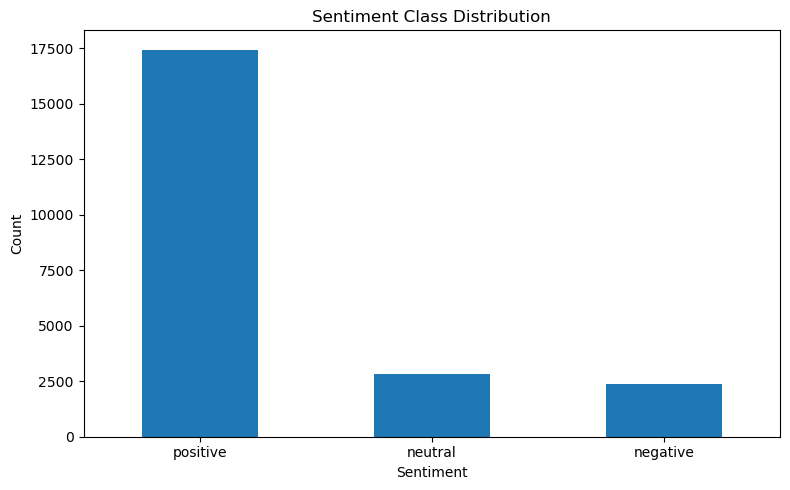

In [12]:
sentiment_counts = df["sentiment"].value_counts()
display(sentiment_counts.to_frame("count"))

sentiment_counts.plot(kind="bar")
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 12. EDA — rating distribution

,count
rating,
1,821
2,1549
3,2823
4,4908
5,12534


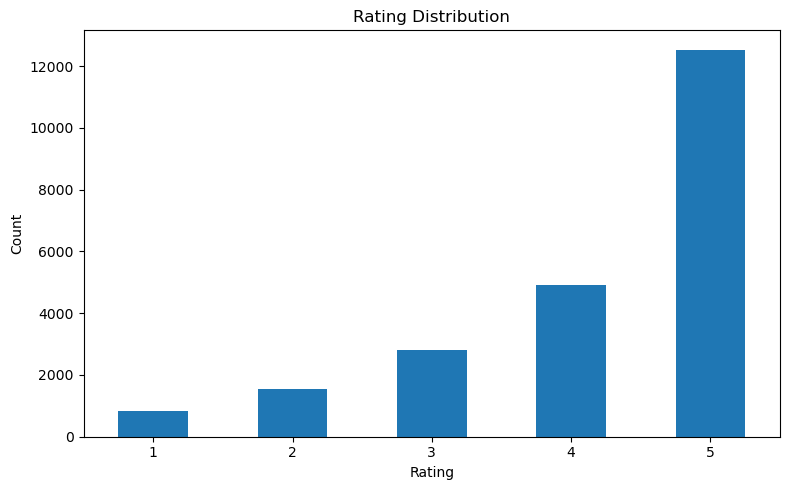

In [13]:
rating_counts = df["rating"].value_counts().sort_index()
display(rating_counts.to_frame("count"))

rating_counts.plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. EDA — review length distribution

,review_length_words
count,22635.000000
mean,63.382461
std,29.248460
min,2.000000
25%,39.000000
50%,62.000000
75%,92.000000
max,119.000000


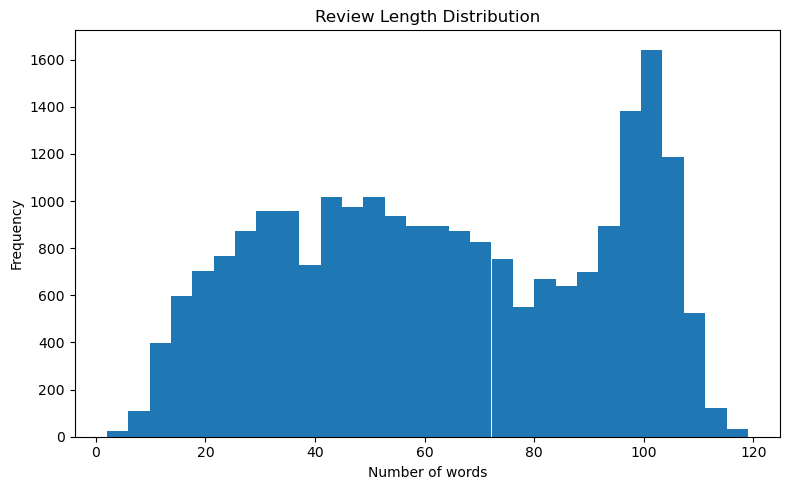

In [14]:
display(df["review_length_words"].describe().to_frame("review_length_words"))

plt.hist(df["review_length_words"], bins=30)
plt.title("Review Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 14. EDA — average review length by sentiment

In [15]:
avg_length = df.groupby("sentiment")["review_length_words"].mean().sort_values()
display(avg_length.to_frame("avg_review_length_words"))

,avg_review_length_words
sentiment,
positive,62.540248
negative,64.219831
neutral,67.883103


## 15. EDA — sentiment by department

sentiment,negative,neutral,positive
department_name,,,
Bottoms,317,407,2937
Dresses,681,830,4634
Intimate,147,177,1326
Jackets,108,90,804
Tops,1096,1300,7650
Trend,21,19,78


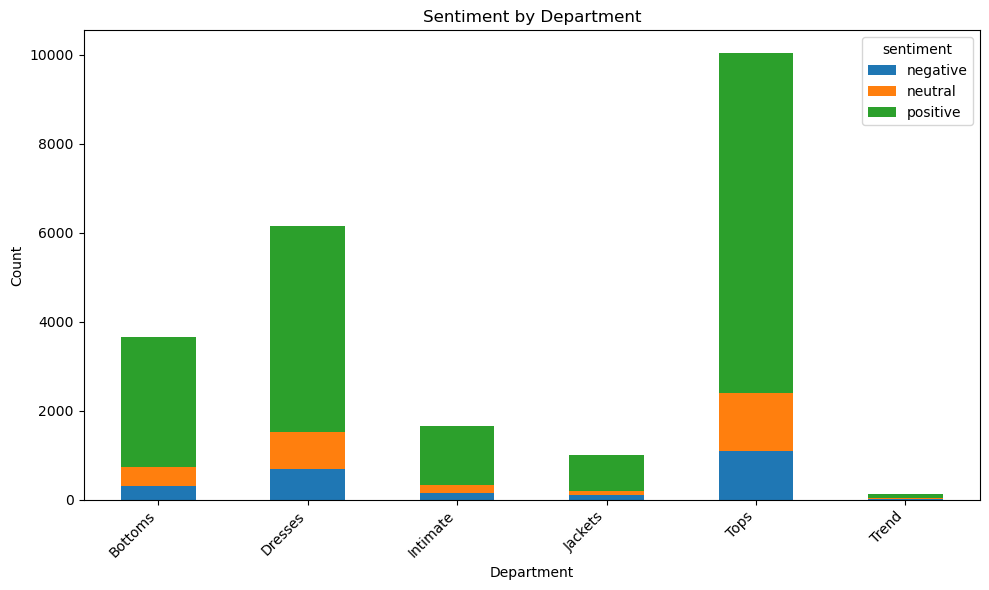

In [16]:
sentiment_by_department = pd.crosstab(df["department_name"], df["sentiment"])
display(sentiment_by_department)

sentiment_by_department.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Sentiment by Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 16. EDA — recommendation indicator vs sentiment

sentiment,negative,neutral,positive
recommended_ind,,,
0,2261,1653,187
1,109,1170,17255


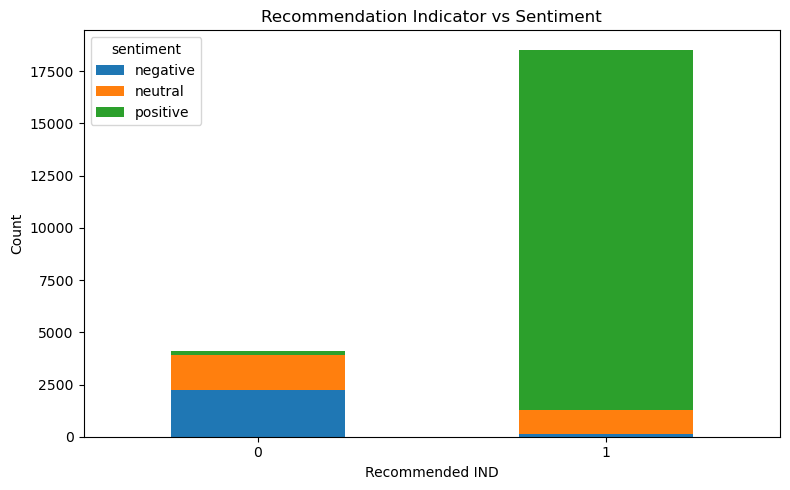

In [17]:
recommendation_sentiment = pd.crosstab(df["recommended_ind"], df["sentiment"])
display(recommendation_sentiment)

recommendation_sentiment.plot(kind="bar", stacked=True)
plt.title("Recommendation Indicator vs Sentiment")
plt.xlabel("Recommended IND")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 17. EDA — average positive feedback count by sentiment

In [18]:
feedback_by_sentiment = df.groupby("sentiment")["positive_feedback_count"].mean().sort_values()
display(feedback_by_sentiment.to_frame("avg_positive_feedback_count"))

,avg_positive_feedback_count
sentiment,
positive,2.431143
neutral,3.198725
negative,3.425316


## 18. EDA — top words by sentiment

This gives a quick first look at common language patterns in each sentiment class.

In [19]:
def top_terms_by_sentiment(dataframe, sentiment_label, top_n=15):
    text_series = dataframe.loc[dataframe["sentiment"] == sentiment_label, "clean_review"]
    vectorizer = CountVectorizer(stop_words="english", max_features=3000)
    matrix = vectorizer.fit_transform(text_series)

    word_counts = np.asarray(matrix.sum(axis=0)).ravel()
    vocab = np.array(vectorizer.get_feature_names_out())

    top_indices = word_counts.argsort()[::-1][:top_n]
    return pd.DataFrame({
        "term": vocab[top_indices],
        "count": word_counts[top_indices]
    })

for label in ["negative", "neutral", "positive"]:
    print(f"\nTop terms for {label}:")
    display(top_terms_by_sentiment(df, label, top_n=15))


Top terms for negative:


,term,count
0,dress,1188
1,like,1141
2,fit,797
3,fabric,782
4,size,687
5,just,687
6,small,573
7,love,533
8,look,530
9,ordered,513



Top terms for neutral:


,term,count
0,dress,1523
1,like,1197
2,fit,1157
3,size,1039
4,just,984
5,fabric,895
6,love,859
7,small,771
8,look,707
9,really,667



Top terms for positive:


,term,count
0,dress,9509
1,love,9420
2,size,7248
3,great,7040
4,fit,5981
5,wear,5510
6,like,5046
7,perfect,4301
8,just,4163
9,color,3856


## 19. Save the cleaned dataset

In [20]:
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_DATA_PATH = OUTPUT_DIR / "cleaned_reviews.csv"
df.to_csv(CLEAN_DATA_PATH, index=False)

print(f"Saved cleaned dataset to: {CLEAN_DATA_PATH.resolve()}")

Saved cleaned dataset to: C:\Users\Owen\Documents\Hertsfordshire\Projects\data\processed\cleaned_reviews.csv


## 20. Key findings from this notebook

You should expect to see:
- a **strong class imbalance**, with positive reviews dominating
- clear alignment between **recommendation indicator** and positive sentiment
- useful metadata fields for later analytics and dashboard filters
- a cleaned text column ready for **TF-IDF vectorization** in the modeling notebook

## Next notebook
The next stage is:
1. train/test split
2. TF-IDF vectorization
3. Logistic Regression, Naive Bayes, and Linear SVM
4. macro F1 comparison
5. confusion matrix and error analysis